In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

main_colours = plt.cm.rainbow(np.linspace(0, 1, 10))

custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "#131313",
    "lines.markeredgewidth": 1.25,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
    "axes.prop_cycle": cycler(color=main_colours),
}

sns.set_theme(context="talk", style="ticks", rc=custom_params)

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

a = 1e-6  # particle radius, m
rho_f = 1000  # fluid density, kg/m^3
deltarho = 50  # particle-fluid density diff, kg/m^3
rho_p = rho_f + deltarho  # colloid density

V = 4 / 3 * np.pi * a**3  # colloid volume
g = 0  # no grav
kBT = 4.19e-21  # Thermal energy
eta = 0.001  # fluid viscosity


m = rho_p * V  # colloid mass
gamma = 6 * np.pi * eta * a  # sotkes drag

tau = m / gamma  # inertial time
vT2 = kBT / m  # sq thermal velocity
vT = np.sqrt(vT2)  # thermal velocity
D = kBT / gamma  # diffusivity


Fg = deltarho * V * g  # buoyant mass, useless
v_sed = Fg / gamma  # sedimentation, useless


tmax = 1000 * tau  # max time

dt_list = tau * np.array([1.5, 1.0, 0.01])  # euler discretisation time steps

ntraj = 1000  # number of trajs

rng = np.random.default_rng(1234)  # rng seed


# ============================================================
# Exact results
# ============================================================


def exact_velocity_variance_from_zero(t):
    # <vtvo> = f(t)
    return vT2 * (1 - np.exp(-2 * t / tau))


def exact_msd_equilibrium_velocity(t):
    # ballistic to diffusive MSD
    return 2 * D * (t - tau * (1 - np.exp(-t / tau)))


def simulate_underdamped_euler(dt):  # func is in thesis
    nsteps = int(np.round(tmax / dt))
    t = np.arange(nsteps + 1) * dt

    x = np.zeros((ntraj, nsteps + 1))
    v = np.zeros((ntraj, nsteps + 1))

    v[:, 0] = rng.normal(0.0, vT, size=ntraj)

    drift_velocity = 0.0

    noise_prefactor = np.sqrt(2 * vT2 / tau)

    for n in range(nsteps):
        wi = rng.normal(0.0, sqrt(dt), size=ntraj)

        v[:, n + 1] = (
            v[:, n] - (dt / tau) * (v[:, n] - drift_velocity) + noise_prefactor * wi
        )

        x[:, n + 1] = x[:, n] + dt * v[:, n]

    return t, x, v


t_fine = np.linspace(0, tmax, 100000)

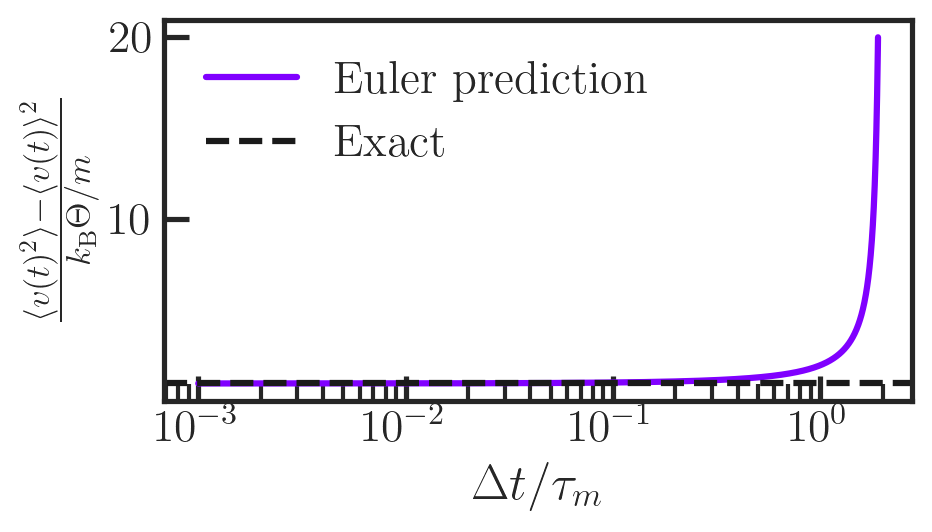

In [18]:
dt_over_tau = np.linspace(0.001, 1.9, 500)


euler_stationary_var = 1 / (1 - dt_over_tau / 2)

plt.figure(figsize=(5, 3))
plt.plot(dt_over_tau, euler_stationary_var, label="Euler prediction")
plt.axhline(1, color="k", linestyle="--", label="Exact")

plt.xscale("log")
plt.xlabel(r"$\Delta t/\tau_m$")
plt.ylabel(
    r"$\frac{\langle v(t)^2 \rangle - \langle v(t) \rangle ^2}{k_\mathrm{B}\Theta / m}$"
)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

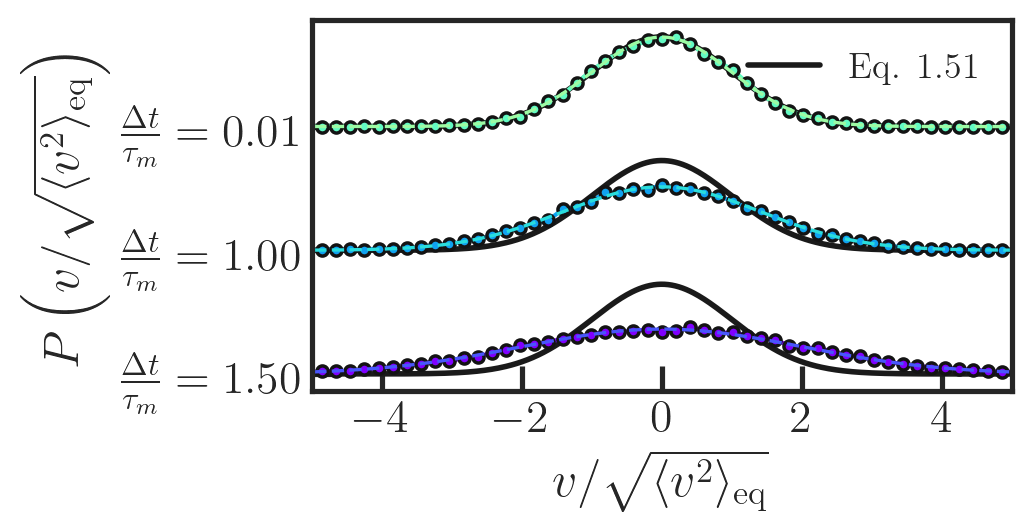

In [19]:
def gaussian_pdf(u, sigma=1.0):
    return np.exp(-0.5 * (u / sigma) ** 2) / (np.sqrt(2 * np.pi) * sigma)


def simulate_stationary_velocities_euler(
    dt,
    n_samples=20_000,
    burn_time=50 * tau,
    seed=4321,
):

    h = dt / tau

    local_rng = np.random.default_rng(seed)
    v = local_rng.normal(0.0, vT, size=n_samples)

    n_burn = int(np.ceil(burn_time / dt))
    noise_prefactor = np.sqrt(2 * vT2 * dt / tau)

    for _ in range(n_burn):
        xi = local_rng.normal(0.0, 1.0, size=n_samples)
        v = (1 - h) * v + noise_prefactor * xi

    return v


velocity_samples = {
    dt: simulate_stationary_velocities_euler(dt, seed=4321 + i)
    for i, dt in enumerate(dt_list)
}


h_values = np.array([dt / tau for dt in dt_list])
sigma_euler_values = np.sqrt(1 / (1 - h_values / 2))
u_lim = max(5.0, 4.5 * np.max(sigma_euler_values))

u_grid = np.linspace(-u_lim, u_lim, 700)
bins = np.linspace(-u_lim, u_lim, 90)

pdf_exact = gaussian_pdf(u_grid, sigma=1.0)


####2

fig, ax = plt.subplots(figsize=(5.5, 3))

offset_step = 0.55
offsets = offset_step * np.arange(len(dt_list))
i = 0
for offset, dt in zip(offsets, dt_list):

    h = dt / tau
    sigma_euler = np.sqrt(1 / (1 - h / 2))
    u = velocity_samples[dt] / vT

    counts, edges = np.histogram(u, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    if i == 0:
        ax.plot(u_grid, pdf_exact + offset, "k-", linewidth=2.0, label="Eq. 1.51")
    else:
        ax.plot(u_grid, pdf_exact + offset, "k-", linewidth=2.0, label=None)
    ax.plot(
        centers, counts + offset, linewidth=1.5, marker="o", markersize=4, label=None
    )
    ax.plot(
        u_grid,
        gaussian_pdf(u_grid, sigma=sigma_euler) + offset,
        "--",
        linewidth=1.2,
    )
    i += 1

ax.set_yticks(offsets)
ax.set_yticklabels([rf"$\frac{{\Delta t}}{{\tau_m}}={dt/tau:.2f}$" for dt in dt_list])
ax.set_xlabel(r"$v/\sqrt{\langle v^2 \rangle_\mathrm{eq}}$")
ax.set_ylabel(rf"$P\left( v/\sqrt{{\langle v^2 \rangle_\mathrm{{eq}}}} \right)$")
ax.legend(frameon=False, fontsize=13.0, loc="upper right", ncols=2)
ax.set_xlim(-5, 5)
# ax.set_ylim(None, 2)
plt.tight_layout()
plt.savefig("pdf_vel.pdf", transparent=True)
plt.show()

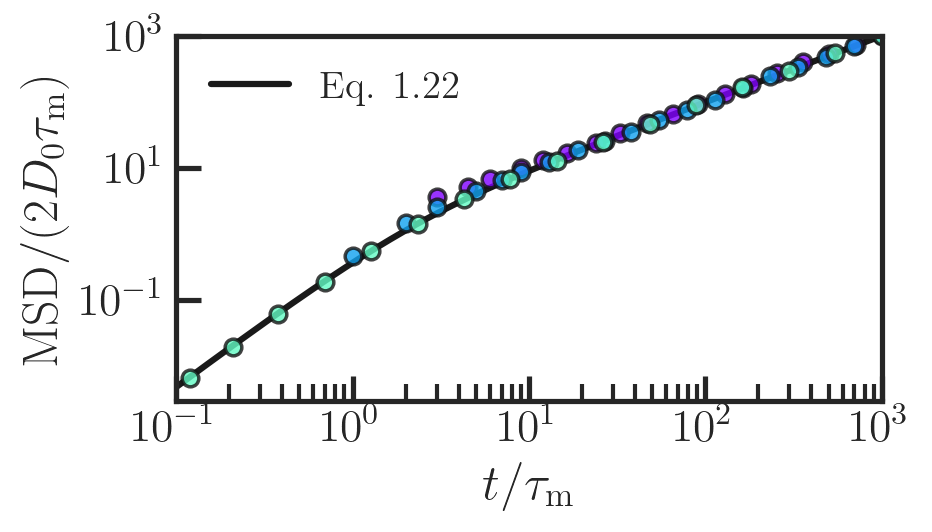

In [20]:
def log_spaced_indices(t, n_points=40):
    positive = np.where(t > 0)[0]

    log_times = np.logspace(
        np.log10(t[positive[0]]), np.log10(t[positive[-1]]), n_points
    )
    indices = np.searchsorted(t, log_times)
    indices = np.unique(np.clip(indices, 0, len(t) - 1))

    return indices


plt.figure(figsize=(5, 3))

plt.loglog(
    t_fine[1:] / tau,
    exact_msd_equilibrium_velocity(t_fine[1:]) / (2 * D * tau),
    "k",
    label="Eq. 1.22",
)

i = 0

for dt in dt_list:
    t, x, v = simulate_underdamped_euler(dt)

    dx = x - x[:, [0]]
    dx_centered = dx - np.mean(dx, axis=0)
    msd = np.mean(dx_centered**2, axis=0)

    idx = log_spaced_indices(t, n_points=20)

    plt.loglog(
        t[idx] / tau,
        msd[idx] / (2 * D * tau),
        "o",
        markersize=6,
        alpha=0.8,
        color=f"C{i}",
    )

    #
    # )
    i += 2


plt.xlabel(r"$t/\tau_\mathrm{m}$")
plt.ylabel(r"$\mathrm{MSD}/(2D_0\tau_\mathrm{m})$")
plt.xlim(1e-1, 1e3)
plt.ylim(3e-3, 1e3)
plt.legend(frameon=False, fontsize=14)
# plt.grid(True, which="both")
plt.tight_layout()
plt.savefig("msd_x.pdf", transparent=True)
plt.show()

# 2D trajectory generation

In [21]:
def simulate_single_trajectory_2d(dt, tmax_traj):
    nsteps = int(np.round(tmax_traj / dt))
    t = np.arange(nsteps + 1) * dt

    x = np.zeros(nsteps + 1)
    y = np.zeros(nsteps + 1)
    vx = np.zeros(nsteps + 1)
    vy = np.zeros(nsteps + 1)

    vx[0] = rng.normal(0.0, vT)
    vy[0] = rng.normal(0.0, vT)

    noise_prefactor = np.sqrt(2 * vT2 * dt / tau)

    for n in range(nsteps):
        xi_x = rng.normal()
        xi_y = rng.normal()

        vx[n + 1] = vx[n] - (dt / tau) * vx[n] + noise_prefactor * xi_x
        vy[n + 1] = vy[n] - (dt / tau) * vy[n] + noise_prefactor * xi_y

        x[n + 1] = x[n] + dt * vx[n]
        y[n + 1] = y[n] + dt * vy[n]

    return t, x, y, vx, vy


dt_traj = 0.01 * tau

tmax_traj = 5000 * tau

t, x, y, vx, vy = simulate_single_trajectory_2d(dt=dt_traj, tmax_traj=tmax_traj)

# A nicer rainbow 2D trajectory

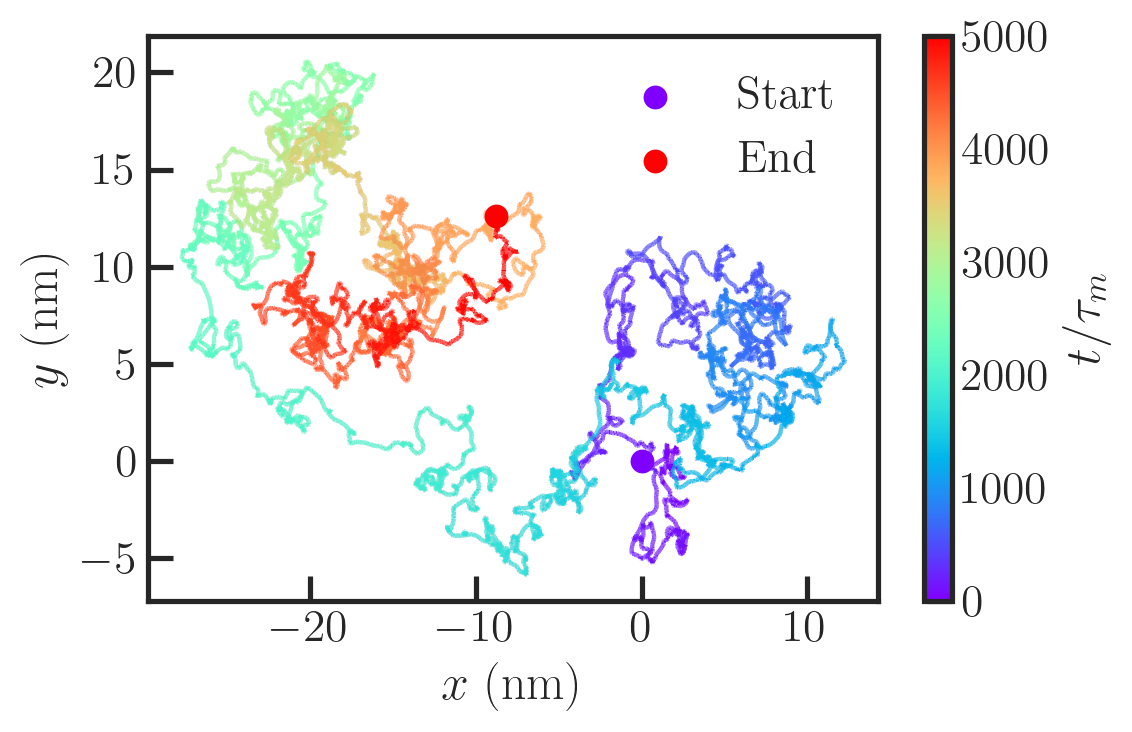

In [22]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

fig, ax = plt.subplots(figsize=(6, 4))

# to nm
x_nm = x * 1e9
y_nm = y * 1e9

points = np.array([x_nm, y_nm]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=t[0] / tau, vmax=t[-1] / tau)

lc = LineCollection(segments, cmap="rainbow", norm=norm, linewidth=1.5)

lc.set_array(t[:-1] / tau)

line = ax.add_collection(lc)

ax.scatter(x_nm[0], y_nm[0], s=50, label="Start", zorder=3, color="C0")
ax.scatter(x_nm[-1], y_nm[-1], s=50, label="End", zorder=3, color="C19")

cbar = fig.colorbar(line, ax=ax)
cbar.set_label(r"$t/\tau_m$")

ax.set_xlabel(r"$x$ (nm)")
ax.set_ylabel(r"$y$ (nm)")
ax.legend(frameon=False, loc="upper right")
# ax.grid(True)

plt.tight_layout()
plt.savefig("2dbrown_traj.pdf", transparent=True)
plt.show()

# MSD plot for thesis

In [23]:
def MSD(x, lags):
    x = np.asarray(x)

    msd = np.zeros(len(lags))

    for n, lag in enumerate(lags):
        if lag >= x.shape[-1]:
            msd[n] = np.nan
        else:
            if x.ndim == 1:
                dx = x[lag:] - x[:-lag]
            elif x.ndim == 2:
                dx = x[:, lag:] - x[:, :-lag]
            else:
                raise ValueError("x must have shape (N,) or (n_traj, N)")

            msd[n] = np.nanmean(dx**2)

    return msd


n_runs = 5
dt = 0.01 * tau
tmax = 5000 * tau

t, x, v = simulate_underdamped_euler(dt)
N = x.shape[-1]

lags = np.unique(
    np.logspace(
        np.log10(1),
        np.log10(N - 1),
        num=20,
        dtype=int,
    )
)

t_msd = lags * dt

msd_runs = np.zeros((n_runs, len(lags)))
msd_runs[0] = MSD(x, lags)

for run in range(1, n_runs):
    t, x, v = simulate_underdamped_euler(dt)
    msd_runs[run] = MSD(x, lags)

msd = np.nanmean(msd_runs, axis=0)
msd_sem = np.nanstd(msd_runs, axis=0) / np.sqrt(n_runs)

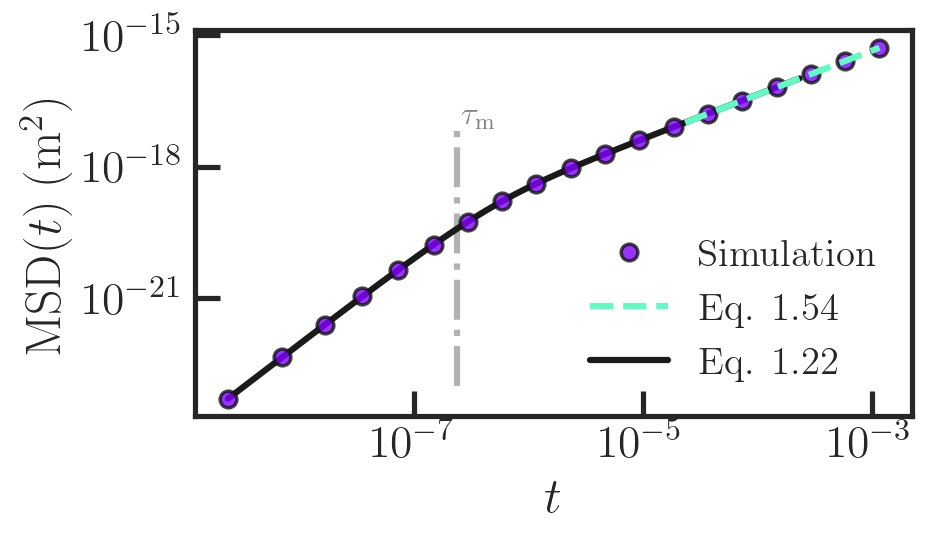

exp D D = 2.30e-13 1.00433637793557
theory v v = 9.76e-04
theory D D = 2.2228640385168054e-13


In [24]:
valid = np.isfinite(msd)

plt.figure(figsize=(5, 3))


plt.loglog(
    t_msd[valid],
    msd[valid],
    "o",
    markersize=6,
    alpha=0.8,
    label=rf"Simulation",
)


def loglog_fit(x, y, xmin, xmax):
    """
    Fits y = A x^alpha in the range xmin < x < xmax.
    Returns alpha, A, and fitted x/y values.
    """
    mask = (x > xmin) & (x < xmax) & (y > 0) & np.isfinite(y)

    logx = np.log10(x[mask])
    logy = np.log10(y[mask])

    alpha, logA = np.polyfit(logx, logy, 1)
    A = 10**logA

    x_fit = np.linspace(xmin, xmax, 100)
    y_fit = A * x_fit**alpha

    return alpha, A, x_fit, y_fit


diffusive_range = (100 * tau, lags[-1] * dt)


alpha_diffusive, A_diffusive, x_diffusive, y_diffusive = loglog_fit(
    t_msd, msd, *diffusive_range
)


plt.loglog(
    x_diffusive,
    y_diffusive,
    "--",
    label="Eq. 1.54",
    color="C4",
)


plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{MSD}(t) \; (\mathrm{m}^2)$")

plt.vlines(
    tau, ymin=1e-23, ymax=1e-17, color="grey", alpha=0.6, linestyle="-.", zorder=-1
)
plt.text(tau * 1.1, 1e-17, r"$\tau_\mathrm{m}$", color="grey", fontsize=12)

plt.loglog(
    t_fine[1:],
    exact_msd_equilibrium_velocity(t_fine[1:]),
    "k",
    label="Eq. 1.22",
    zorder=-1,
)


plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.savefig(
    "/Users/juls/Desktop/thesis/figures/chapter1/msd_x_results.pdf", transparent=True
)
plt.show()

D_fit = A_diffusive / 2


print("exp D", f"D = {D_fit:.2e}", alpha_diffusive)
print("theory v", f"v = {vT:.2e}")
print("theory D", f"D = {D}")